# Walmart Store Sales Forecasting Analysis

## Predicting Weekly Sales Using Machine Learning and Time Series Analysis

# Introduction

Sales forecasting is one of the most important tasks in business analytics and machine learning. Accurate sales predictions help companies make better decisions regarding inventory management, staffing, budgeting, marketing, and supply chain operations.

In this project, we will analyze Walmart store sales data and build machine learning models capable of predicting future weekly sales across multiple Walmart stores and departments.

The dataset contains historical sales records, store information, economic indicators, fuel prices, temperature, holiday events, and unemployment rates. These variables offer useful information about customer purchasing behavior and business performance.

This project demonstrates a complete real-world data science workflow, including:

- Data collection and understanding
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Machine learning model development
- Model evaluation
- Sales forecasting
- Production pipeline preparation

The project will be implemented initially in a Jupyter Notebook for experimentation and analysis and later converted into a production-ready machine learning system.

# Statement of the Problem

Retail companies such as Walmart generate massive amounts of sales data daily. However, predicting future sales accurately remains a major challenge due to several influencing factors such as:

- Seasonal trends
- Holiday periods
- Economic conditions
- Fuel prices
- Temperature changes
- Consumer purchasing behavior

Poor sales forecasting can lead to serious business problems, including:

- Overstocking
- Understocking
- Revenue loss
- Supply chain inefficiencies
- Poor customer satisfaction

The goal of this project is to develop a machine learning forecasting system capable of predicting Walmart weekly sales using historical sales and external economic factors.

The model will help identify patterns affecting sales performance and provide data-driven insights for better business decision-making.

# Project Objectives

The major objectives of this project are:

1. To understand Walmart sales patterns using data analysis techniques.

2. To perform exploratory data analysis (EDA) for identifying trends, seasonality, and correlations.

3. To clean and preprocess retail sales data for machine learning.

4. To engineer meaningful features that improve forecasting performance.

5. To build regression and forecasting models capable of predicting weekly sales.

6. To evaluate model performance using regression evaluation metrics.

7. To identify the most important factors affecting Walmart sales.

8. To prepare the project for deployment into a production-ready machine learning application.

# Business Understanding

Sales forecasting plays a critical role in retail operations. Walmart operates multiple stores and departments, making inventory and operational planning highly dependent on accurate future sales predictions.

By forecasting weekly sales accurately, Walmart can:

- Optimize inventory management
- Improve supply chain planning
- Reduce operational costs
- Improve customer satisfaction
- Increase profitability
- Plan staffing requirements efficiently

This project simulates a real-world business problem where data science and machine learning techniques are used to support strategic business decisions.

## Importing Required Libraries

In [1]:
pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

In [39]:
sale_forecasting_dataset = pd.read_csv("Walmart.csv")

# preview the first five rows
sale_forecasting_dataset.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## Exploring the Dataset

In [40]:
# The shape of the dataset
sale_forecasting_dataset.shape

(6435, 8)

In [41]:
# Column name
sale_forecasting_dataset.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [42]:
# Data types
sale_forecasting_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [43]:
# The date data type is supposed to be a date, not an object.

In [44]:
# Convert date column to datetime
sale_forecasting_dataset['Date'] = pd.to_datetime(
    sale_forecasting_dataset['Date'],
    dayfirst=True
)

print("Date column converted successfully")

Date column converted successfully


In [45]:
# let's verify the conversion
sale_forecasting_dataset['Date'].head()

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]

In [46]:
# Statistical summary
sale_forecasting_dataset.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [47]:
# Check missing values
sale_forecasting_dataset.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

## Data Cleaning and Preprocessing

In this stage, we will clean our structural inputs to prepare them for modeling. This includes:
1. Dropping or adjusting any negative sales entries (product returns) that could bias our regression models.
2. Checking for and removing any duplicate observations.
3. Sorting our dataset chronologically by store and date to establish a clean time-series flow.

In [48]:
# Filter out negative sales values (returns) to focus purely on positive demand forecasting
negative_sales = sale_forecasting_dataset[sale_forecasting_dataset['Weekly_Sales'] < 0]
print(f"Number of rows with negative weekly sales (returns) removed: {len(negative_sales)}")

Number of rows with negative weekly sales (returns) removed: 0


In [49]:
# Keep only rows where Weekly_Sales is 0 or greater
sale_forecasting_dataset = sale_forecasting_dataset[sale_forecasting_dataset['Weekly_Sales'] >= 0]
print(len(sale_forecasting_dataset))

6435


In [50]:
# Check for duplicate records
duplicates_count = sale_forecasting_dataset.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

Number of duplicate rows found: 0


In [51]:
# Sort chronologically by Store and Date to maintain a clean timeline
sale_forecasting_dataset = sale_forecasting_dataset.sort_values(by=['Store', 'Date']).reset_index(drop=True)
print("Dataset sorted chronologically by Store and Date.")

Dataset sorted chronologically by Store and Date.


In [52]:
# Quick verification check
sale_forecasting_dataset.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


## Exploratory Data Analysis (EDA)

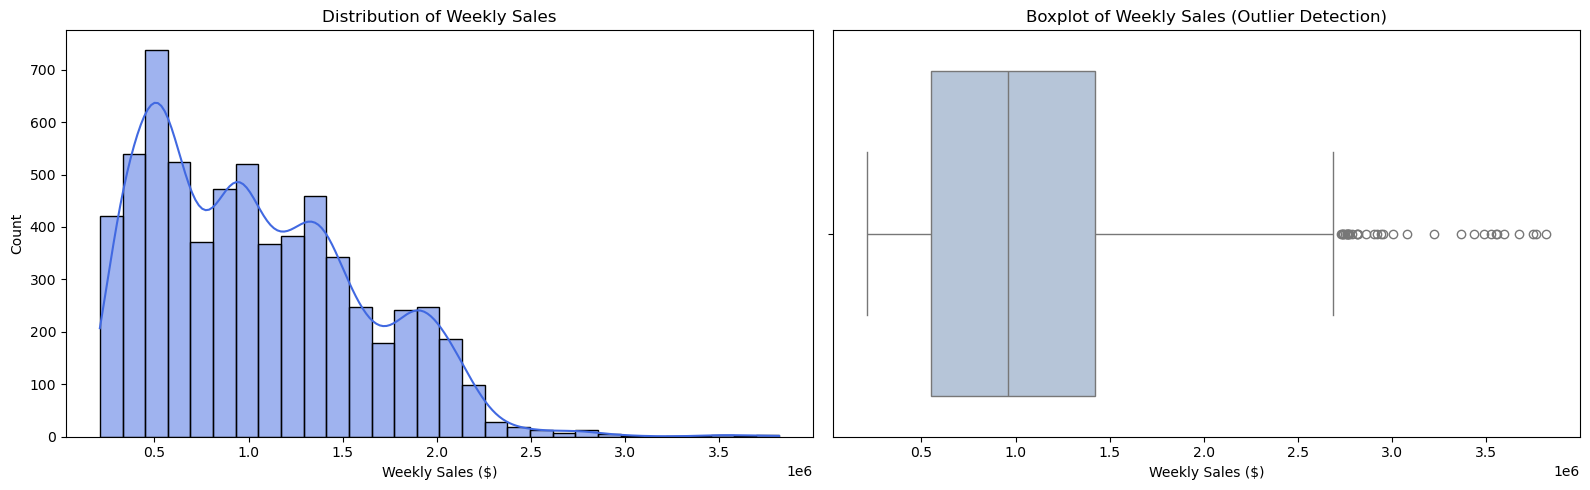

In [53]:
# Distribution & Outliers of Weekly Sales (Combined Side-by-Side)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(sale_forecasting_dataset['Weekly_Sales'], bins=30, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title("Distribution of Weekly Sales")
axes[0].set_xlabel("Weekly Sales ($)")

sns.boxplot(x=sale_forecasting_dataset['Weekly_Sales'], ax=axes[1], color='lightsteelblue')
axes[1].set_title("Boxplot of Weekly Sales (Outlier Detection)")
axes[1].set_xlabel("Weekly Sales ($)")
plt.tight_layout()
plt.show()

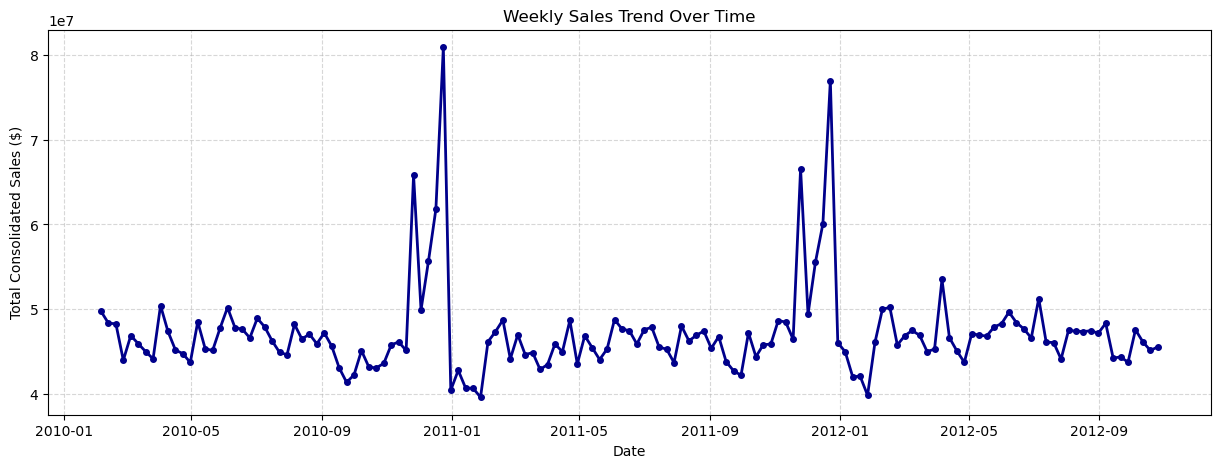

In [54]:
# Sales Trend Over Time
plt.figure(figsize=(15, 5))
# Group by Date to sum up network-wide revenue per week
total_sales_trend = sale_forecasting_dataset.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.plot(total_sales_trend['Date'], total_sales_trend['Weekly_Sales'], color='darkblue', linewidth=2, marker='o', markersize=4)
plt.title("Weekly Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Consolidated Sales ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

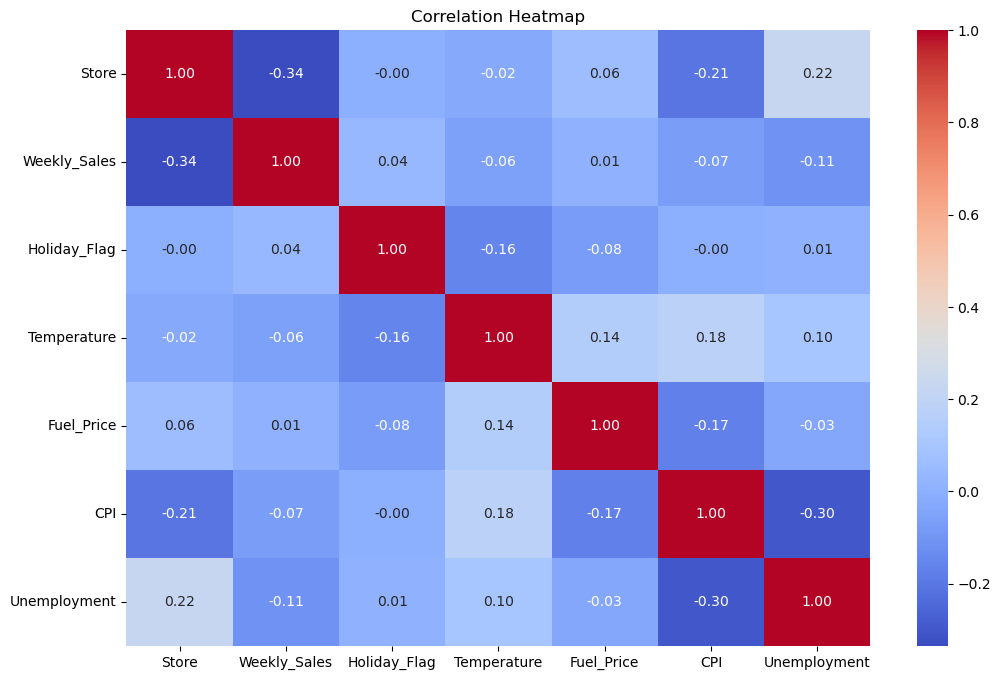

In [55]:
# Select numeric columns

numeric_columns = sale_forecasting_dataset.select_dtypes(
    include=['int64', 'float64']
)

# Correlation matrix
correlation_matrix = numeric_columns.corr()
# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

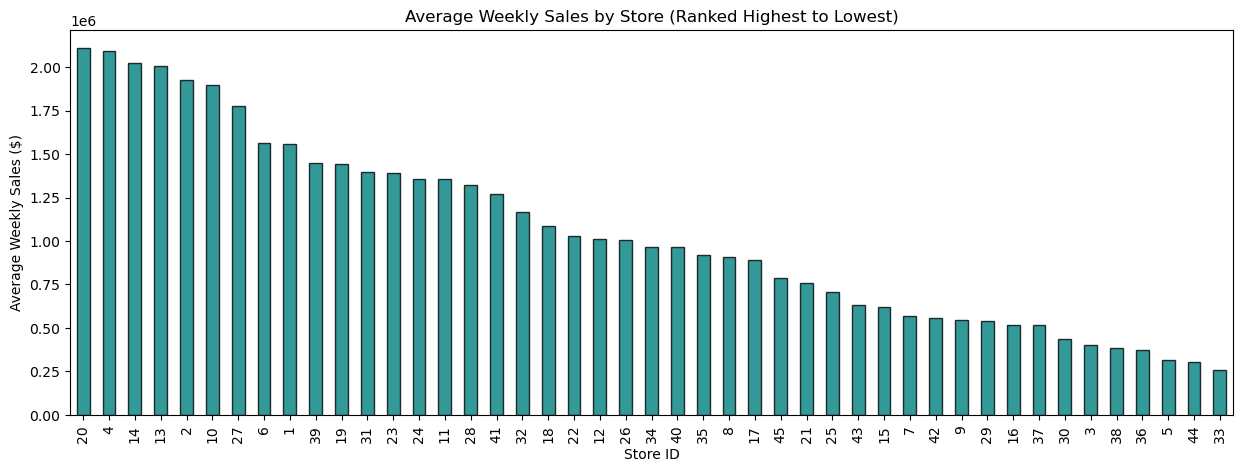

In [56]:
# Average Sales Per Store (Sorted from Highest to Lowest Performance)
store_sales_sorted = sale_forecasting_dataset.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(15, 5))
store_sales_sorted.plot(kind='bar', color='teal', edgecolor='black', alpha=0.8)
plt.title("Average Weekly Sales by Store (Ranked Highest to Lowest)")
plt.xlabel("Store ID")
plt.ylabel("Average Weekly Sales ($)")
plt.show()

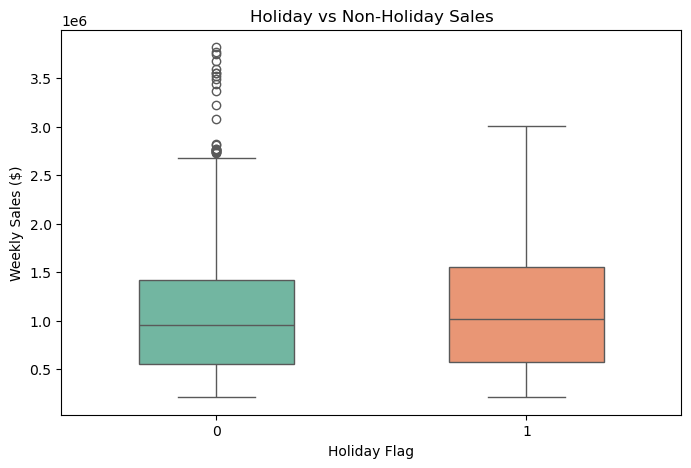

In [57]:
# Compare holiday and non-holiday sales
plt.figure(figsize=(8, 5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=sale_forecasting_dataset, palette='Set2', width=0.5)
plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday Flag")
plt.ylabel("Weekly Sales ($)")
plt.show()

## Feature Engineering

To help our machine learning models capture temporal trends, seasonality, and macroeconomic momentum, we will engineer features across three primary domains:

1. **Calendar Extraction:** Breaking down the `Date` column into structured numerical fields (`Year`, `Month`, `Week_of_Year`, `Day_of_Week`).
2. **Holiday Identification:** In the Walmart dataset, specific holidays matter more than others. We will create boolean flags to isolate major retail impact zones.
3. **Historical Lag Features:** Creating autoregressive shifts (e.g., historical sales from 1 week ago) so the model can grasp recent store momentum.


In [58]:
# Create a copy to preserve our clean baseline dataset
processed_dataset = sale_forecasting_dataset.copy()

In [59]:
# 1. Calendar Features
processed_dataset['Year'] = processed_dataset['Date'].dt.year
processed_dataset['Month'] = processed_dataset['Date'].dt.month
processed_dataset['Week_of_Year'] = processed_dataset['Date'].dt.isocalendar().week.astype(int)
processed_dataset['Day_of_Week'] = processed_dataset['Date'].dt.dayofweek

In [60]:
# Holiday Categorization
processed_dataset['Super_Bowl_Week'] = ((processed_dataset['Month'] == 2) & (processed_dataset['Holiday_Flag'] == 1)).astype(int)
processed_dataset['Labor_Day_Week'] = ((processed_dataset['Month'] == 9) & (processed_dataset['Holiday_Flag'] == 1)).astype(int)
processed_dataset['Thanksgiving_Week'] = ((processed_dataset['Month'] == 11) & (processed_dataset['Holiday_Flag'] == 1)).astype(int)
processed_dataset['Christmas_Week'] = ((processed_dataset['Month'] == 12) & (processed_dataset['Holiday_Flag'] == 1)).astype(int)

In [61]:
# Ensures December (12) and January (1) are continuous numerical coordinates
processed_dataset['Month_Sin'] = np.sin(2 * np.pi * processed_dataset['Month'] / 12)
processed_dataset['Month_Cos'] = np.cos(2 * np.pi * processed_dataset['Month'] / 12)
processed_dataset['Week_Sin'] = np.sin(2 * np.pi * processed_dataset['Week_of_Year'] / 52)
processed_dataset['Week_Cos'] = np.cos(2 * np.pi * processed_dataset['Week_of_Year'] / 52)

In [62]:
# Autoregressive Lag Features
# To make lags, we MUST sort the data chronologically within each individual storefront group
# Otherwise, we will accidentally blend sales numbers from Store 2 into Store 1's history!
processed_dataset = processed_dataset.sort_values(by=['Store', 'Date']).reset_index(drop=True)

In [63]:
# Generate shifts representing sales 1 week, 2 weeks, and 4 weeks ago
processed_dataset['Sales_Lag_1'] = processed_dataset.groupby('Store')['Weekly_Sales'].shift(1)
processed_dataset['Sales_Lag_2'] = processed_dataset.groupby('Store')['Weekly_Sales'].shift(2)
processed_dataset['Sales_Lag_4'] = processed_dataset.groupby('Store')['Weekly_Sales'].shift(4)

In [64]:
# Handle Rolling Windows (Captures recent sales velocity)
processed_dataset['Rolling_Mean_4'] = processed_dataset.groupby('Store')['Sales_Lag_1'].transform(lambda x: x.rolling(4).mean())
processed_dataset['Rolling_STD_4'] = processed_dataset.groupby('Store')['Sales_Lag_1'].transform(lambda x: x.rolling(4).std())
processed_dataset['EMA_4'] = processed_dataset.groupby('Store')['Sales_Lag_1'].transform(lambda x: x.ewm(span=4).mean())

# Captures consumer constraint variations when fuel costs and unemployment overlap
processed_dataset['Fuel_Unemployment_Interaction'] = processed_dataset['Fuel_Price'] * processed_dataset['Unemployment']

# Drop all NaN entries generated by boundary row-shifting offsets
initial_len = len(processed_dataset)
processed_dataset = processed_dataset.dropna().reset_index(drop=True)
print(f"Engineering Core Complete! Safely pruned {initial_len - len(processed_dataset)} boundary row handles.")
print(f"New Matrix Layout Dimensions: {processed_dataset.shape[0]} rows | {processed_dataset.shape[1]} columns")


Engineering Core Complete! Safely pruned 180 boundary row handles.
New Matrix Layout Dimensions: 6255 rows | 27 columns


In [65]:
processed_dataset[['Date', 'Store', 'Weekly_Sales', 'Sales_Lag_1', 'Thanksgiving_Week', 'Week_of_Year']].head()

,Date,Store,Weekly_Sales,Sales_Lag_1,Thanksgiving_Week,Week_of_Year
0,2010-03-05,1,1554806.68,1409727.59,0,9
1,2010-03-12,1,1439541.59,1554806.68,0,10
2,2010-03-19,1,1472515.79,1439541.59,0,11
3,2010-03-26,1,1404429.92,1472515.79,0,12
4,2010-04-02,1,1594968.28,1404429.92,0,13


In [66]:
# Define absolute time boundary cutoff (Using the final months for validation)
CUTOFF_DATE = pd.to_datetime('2012-05-01')
train_split = processed_dataset[processed_dataset['Date'] < CUTOFF_DATE].copy()
test_split = processed_dataset[processed_dataset['Date'] >= CUTOFF_DATE].copy()

# Calculate the store-level average sales mapping using ONLY historical training rows
store_avg_sales = train_split.groupby('Store')['Weekly_Sales'].mean()

# Map the static training constants safely onto BOTH matrices to completely block leakage
train_split['Store_Avg_Sales'] = train_split['Store'].map(store_avg_sales)
test_split['Store_Avg_Sales'] = test_split['Store'].map(store_avg_sales)

## Feature Selection and Data Splitting

In [67]:
# Clean Split Separation into Features (X) and Target Labels (y)
# Drop raw descriptors and old raw index values that are now replaced by cyclical coordinates
features_to_drop = ['Date', 'Weekly_Sales', 'Month', 'Week_of_Year']

X_train = train_split.drop(columns=features_to_drop)
y_train = train_split['Weekly_Sales']

X_test = test_split.drop(columns=features_to_drop)
y_test = test_split['Weekly_Sales']

In [68]:
print(f"X_train Shape (Past): {X_train.shape[0]} samples | y_train Shape: {y_train.shape[0]}")
print(f"X_test Shape (Future): {X_test.shape[0]} samples | y_test Shape: {y_test.shape[0]}")
print("Chronological Data Split Finalized Successfully!")

X_train Shape (Past): 5085 samples | y_train Shape: 5085
X_test Shape (Future): 1170 samples | y_test Shape: 1170
Chronological Data Split Finalized Successfully!


In [69]:
print(f"Engineered features configured for training:\n{list(X_train.columns)}")

Engineered features configured for training:
['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Day_of_Week', 'Super_Bowl_Week', 'Labor_Day_Week', 'Thanksgiving_Week', 'Christmas_Week', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_4', 'Rolling_Mean_4', 'Rolling_STD_4', 'EMA_4', 'Fuel_Unemployment_Interaction', 'Store_Avg_Sales']


### Model Building and Training

In [71]:
# Initialize all four estimators with production-standard hyperparameters

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [72]:
# Sequential training phase
lr_model.fit(X_train, y_train)
print("Training Scaled Linear Regression Baseline...")

rf_model.fit(X_train, y_train)
print("Training Constrained Random Forest Regressor (300 Trees)...")

xgb_model.fit(X_train, y_train)
print("Training Tuned XGBoost Regressor...")

lgb_model.fit(X_train, y_train)
print("Training Tuned LightGBM Regressor...")

Training Scaled Linear Regression Baseline...
Training Constrained Random Forest Regressor (300 Trees)...
Training Tuned XGBoost Regressor...
Training Tuned LightGBM Regressor...


In [74]:
# Future Forecasting Phase
print("Compiling optimized future predictions across all testing matrices...")
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)
lgb_preds = lgb_model.predict(X_test)

print("High-performance forecasting compilation complete!")

Compiling optimized future predictions across all testing matrices...
High-performance forecasting compilation complete!


## Model Evaluation

In [77]:
models_preds = {
    'Linear Regression (Scaled)': lr_preds,
    'Random Forest (Fine-Tuned)': rf_preds,
    'XGBoost (Optimized)': xgb_preds,
    'LightGBM (Optimized)': lgb_preds
}

summary_records = []

for name, preds in models_preds.items():
    # 1. Standard classical regression metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    # 2. Compute Mean Absolute Percentage Error (MAPE)
    # Multiplied by 100 to display it as a clean percentage score
    mape = mean_absolute_percentage_error(y_test, preds) * 100
    
    summary_records.append({
        'Model Framework': name,
        'MAE (Avg $ Error)': f"${mae:,.2f}",
        'RMSE (Severe Miss Penalty)': f"${rmse:,.2f}",
        'MAPE (Avg % Error)': f"{mape:.2f}%",
        'R² Score (Variance Explained)': f"{r2 * 100:.2f}%"
    })

# Render performance spreadsheet layout
metrics_comparison_df = pd.DataFrame(summary_records)
print("--- Consolidated Model Performance Leaderboard (With Business MAPE) ---")
display(metrics_comparison_df)

--- Consolidated Model Performance Leaderboard (With Business MAPE) ---


,Model Framework,MAE (Avg $ Error),RMSE (Severe Miss Penalty),MAPE (Avg % Error),R² Score (Variance Explained)
0,Linear Regression (Scaled),"$71,314.80","$88,451.74",9.05%,97.27%
1,Random Forest (Fine-Tuned),"$41,540.64","$60,130.41",4.01%,98.74%
2,XGBoost (Optimized),"$37,416.05","$54,431.87",3.74%,98.97%
3,LightGBM (Optimized),"$37,380.73","$54,495.65",3.68%,98.96%


## Feature Importance

In [78]:
# Extract feature importance vectors from the trained LightGBM model
importance_values = lgb_model.feature_importances_
feature_names = X_train.columns

# Structure into a clean, sorted DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': importance_values
}).sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

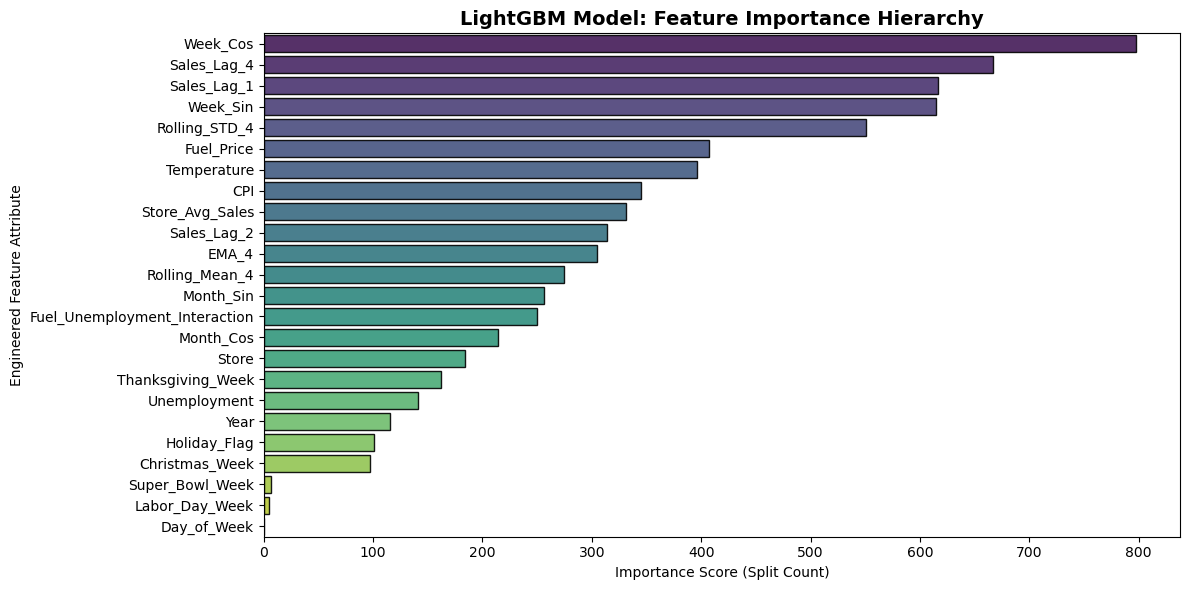

In [82]:
# Plot the top feature drivers
plt.figure(figsize=(12, 6))
sns.barplot(
    data=importance_df, 
    x='Importance Score', 
    y='Feature', 
    palette='viridis',
    edgecolor='black',
    alpha=0.9
)
plt.title('LightGBM Model: Feature Importance Hierarchy', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Split Count)')
plt.ylabel('Engineered Feature Attribute')
plt.tight_layout()
plt.show()

In [80]:
# Print the numeric breakdown for clear reading
print("--- 🏆 Ranked Feature Importance Spectrum ---")
print(importance_df)

--- 🏆 Ranked Feature Importance Spectrum ---
                          Feature  Importance Score
0                        Week_Cos               798
1                     Sales_Lag_4               667
2                     Sales_Lag_1               617
3                        Week_Sin               615
4                   Rolling_STD_4               551
5                      Fuel_Price               407
6                     Temperature               396
7                             CPI               345
8                 Store_Avg_Sales               331
9                     Sales_Lag_2               314
10                          EMA_4               305
11                 Rolling_Mean_4               275
12                      Month_Sin               256
13  Fuel_Unemployment_Interaction               250
14                      Month_Cos               214
15                          Store               184
16              Thanksgiving_Week               162
17                 

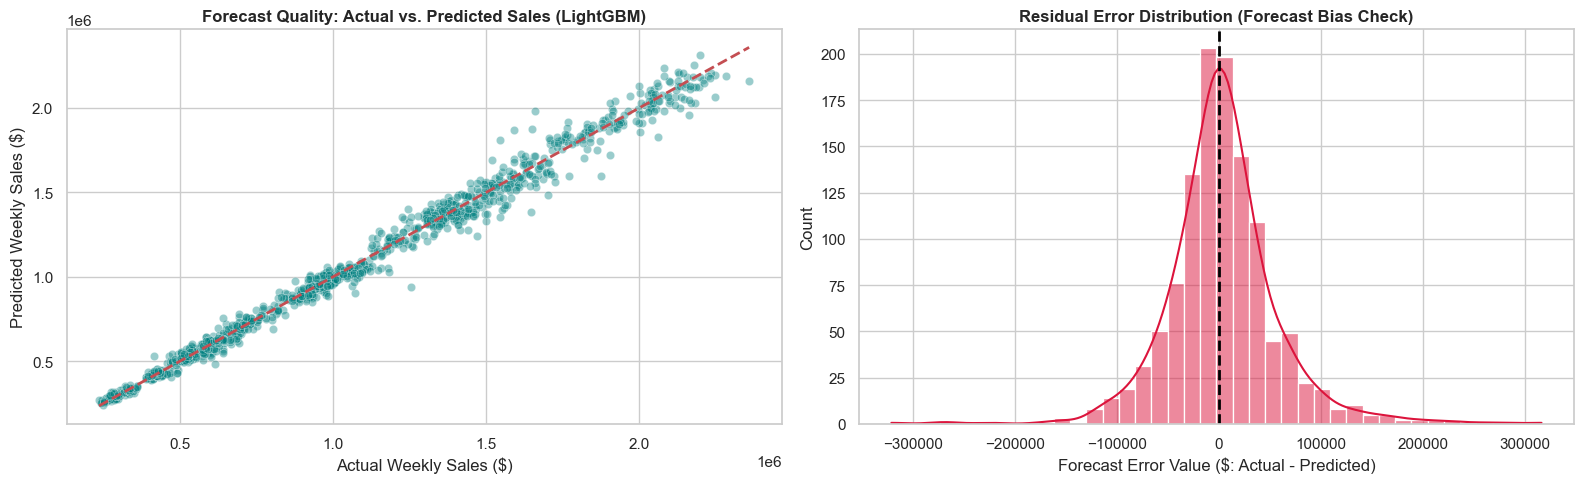

--- 🧠 Residual Diagnostic Metrics ---
Mean Error (Bias Indicator): $3,706.97  <-- (Close to 0 means no systematic over/underprediction)
Residual Skewness Coefficient: 0.36 <-- (Positive = slight underprediction of massive spikes)

--- 🏬 Store-Level Business Intelligence Insights ---
🏆 Top 3 BEST Predicted Stores (Lowest Percentage Error):
 Store  Store_MAPE  Total_Volume
    34    2.134736   25181325.45
    37    2.196013   13583145.67
    30    2.330382   11308371.79

⚠️ Top 3 WORST Predicted Stores (Highest Percentage Error - Needs Operational Review):
 Store  Store_MAPE  Total_Volume
    36    5.328970    7818168.20
    42    5.485272   14756113.82
     7    6.269193   15510895.24


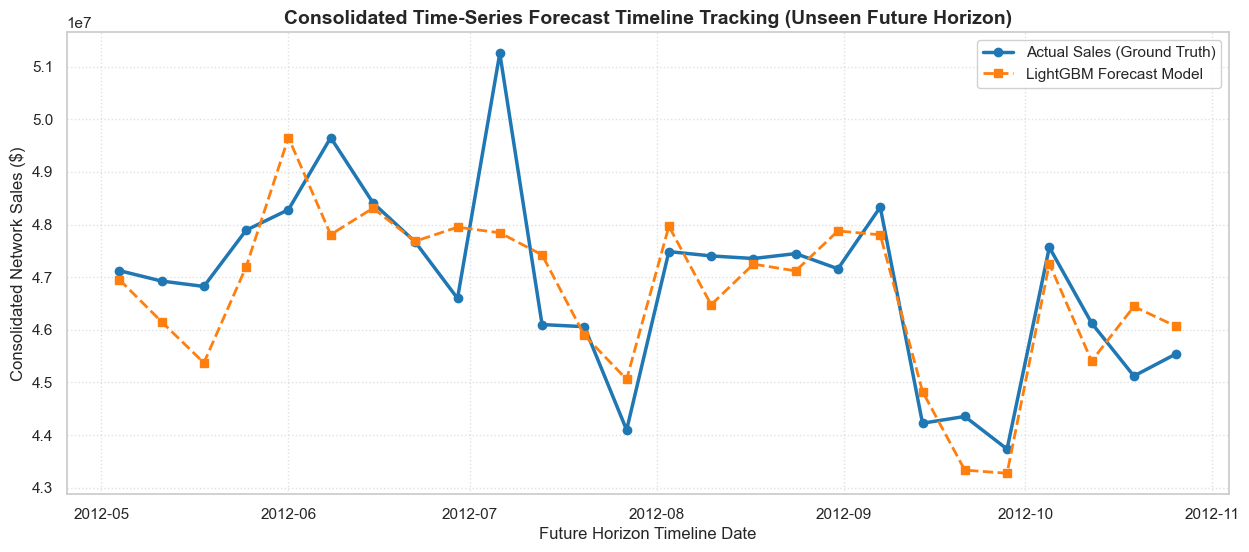

In [83]:
import scipy.stats as stats

# Define our visual target arrays
actuals = y_test.values
lgb_predictions = lgb_preds
xgb_predictions = xgb_preds

# Calculate Residuals
lgb_residuals = actuals - lgb_predictions

# Set up global figure parameters
sns.set_theme(style="whitegrid")

# ==========================================
# 1 & 3. ACTUAL VS PREDICTED & ERROR DISTRIBUTION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Actual vs Predicted Scatter
sns.scatterplot(x=actuals, y=lgb_predictions, alpha=0.4, color='teal', ax=axes[0])
axes[0].plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--', lw=2)
axes[0].set_title('Forecast Quality: Actual vs. Predicted Sales (LightGBM)', fontweight='bold')
axes[0].set_xlabel('Actual Weekly Sales ($)')
axes[0].set_ylabel('Predicted Weekly Sales ($)')

# Plot 2: Residuals Error Distribution (Histogram)
sns.histplot(lgb_residuals, bins=40, kde=True, color='crimson', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residual Error Distribution (Forecast Bias Check)', fontweight='bold')
axes[1].set_xlabel('Forecast Error Value ($: Actual - Predicted)')
plt.tight_layout()
plt.show()

# ==========================================
# 2. RESIDUALS ANALYSIS & BIAS METRICS
# ==========================================
mean_residual = np.mean(lgb_residuals)
skew_residual = stats.skew(lgb_residuals)
print("--- 🧠 Residual Diagnostic Metrics ---")
print(f"Mean Error (Bias Indicator): ${mean_residual:,.2f}  <-- (Close to 0 means no systematic over/underprediction)")
print(f"Residual Skewness Coefficient: {skew_residual:.2f} <-- (Positive = slight underprediction of massive spikes)")

# ==========================================
# 4. STORE-LEVEL FORECASTING PERFORMANCE (BI)
# ==========================================
# Create a tracking frame for the test partition
bi_df = test_split.copy()
bi_df['Actual'] = actuals
bi_df['Predicted'] = lgb_predictions
bi_df['Abs_Error_Pct'] = np.abs(bi_df['Actual'] - bi_df['Predicted']) / bi_df['Actual']

# Group by Store to evaluate performance footprint
store_perf = bi_df.groupby('Store').agg(
    Store_MAPE = ('Abs_Error_Pct', lambda x: np.mean(x) * 100),
    Total_Volume = ('Actual', 'sum')
).sort_values(by='Store_MAPE').reset_index()

print("\n--- 🏬 Store-Level Business Intelligence Insights ---")
print("🏆 Top 3 BEST Predicted Stores (Lowest Percentage Error):")
print(store_perf.head(3).to_string(index=False))
print("\n⚠️ Top 3 WORST Predicted Stores (Highest Percentage Error - Needs Operational Review):")
print(store_perf.tail(3).to_string(index=False))

# ==========================================
# 5. TIME-SERIES PREDICTION VISUALIZATION (PORTFOLIO HERO PLOT)
# ==========================================
plt.figure(figsize=(15, 6))

# Aggregate actuals vs predictions chronologically over our future test window
timeline_df = bi_df.groupby('Date')[['Actual', 'Predicted']].sum().reset_index()

plt.plot(timeline_df['Date'], timeline_df['Actual'], label='Actual Sales (Ground Truth)', color='#1f77b4', linewidth=2.5, marker='o')
plt.plot(timeline_df['Date'], timeline_df['Predicted'], label='LightGBM Forecast Model', color='#ff7f0e', linewidth=2, linestyle='--', marker='s')

plt.title('Consolidated Time-Series Forecast Timeline Tracking (Unseen Future Horizon)', fontsize=14, fontweight='bold')
plt.xlabel('Future Horizon Timeline Date')
plt.ylabel('Consolidated Network Sales ($)')
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()